# 10 · Intervention spectrum — scope and direction

Every intervention is one `process(StateChange(...))`. Two comparisons, each
holding one thing fixed:

- **Scope** — the *same* operation (zero-ablation) applied to more and more units:
  one unit, one region, a whole layer. Effect should grow with the number of units.
- **Direction** — the *same* unit, lesioned (zeroed) vs stimulated (`drive`). These
  push the output in opposite directions.

Effect size = L2 norm of the output change; signed shift = mean(output - baseline).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore_core.model_interface import BrainScoreModel, StateChange, Selection, Perturbation
from brainscore.perturbation import build_pytorch_ablation_fn
torch.manual_seed(0)

# A small fixed MLP: 64 inputs -> 32 -> 16 -> 4 outputs. Module '3' is the 32->16 Linear (16 units).
net = nn.Sequential(nn.Flatten(), nn.Linear(64, 32), nn.ReLU(),
                    nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 4)).eval()
# Wrap the net so process(StateChange) dispatches to a hook-based ablation function.
bs = BrainScoreModel('interv', None, {}, {}, None, state_change_fn=build_pytorch_ablation_fn(net))
# One fixed probe input; `base` is its output before any intervention.
x = torch.randn(1, 64)
with torch.no_grad(): base = net(x).clone()

def apply(target, pert):
    '''Apply `pert` to the `target` units, measure output change vs baseline, then undo it. Returns (L2 magnitude, signed mean shift).'''
    a = bs.process(StateChange(kind='ablation', target=target, perturbation=pert))
    with torch.no_grad(): out = net(x).clone()
    bs.process(StateChange(kind='reset', handle_id=a.handle_id))
    return float((out - base).norm()), float((out - base).mean())

## Scope: same operation, more units

Zero-ablation of 1 unit of L3, then 8, then all 16 — same layer, same kind, growing count.

In [2]:
# Same operation (zero-out), widening the selection: 1 unit -> 8 units -> whole layer.
scope = [('1 unit of L3', Selection('3', [5])),
         ('8 units of L3', Selection('3', list(range(8)))),
         ('all 16 of L3', Selection('3'))]
# Effect size should grow as more units are lesioned.
for name, target in scope:
    eff, _ = apply(target, Perturbation(kind='zero'))
    print(f'{name:24s} effect = {eff:.3f}')

1 unit of L3             effect = 0.047
8 units of L3            effect = 0.202
all 16 of L3             effect = 0.257


## Direction: same unit, lesion vs stimulation

Unit 5 of L3, zeroed (lesion) vs driven by +8 (stimulation). The signed shift is opposite: removing the unit vs amplifying it move the output the other way.

In [3]:
# Same single unit, opposite interventions: zero it out (lesion) vs drive it up (stimulate).
_, lesion_shift = apply(Selection('3', [5]), Perturbation(kind='zero'))
_, stim_shift = apply(Selection('3', [5]), Perturbation(kind='drive', amount=8.0))
print(f'lesion unit 5:      signed shift = {lesion_shift:+.3f}')
print(f'stimulate unit 5:   signed shift = {stim_shift:+.3f}')
print('opposite directions:', (lesion_shift < 0) != (stim_shift < 0))

lesion unit 5:      signed shift = -0.020
stimulate unit 5:   signed shift = +0.846
opposite directions: True


## The two comparisons

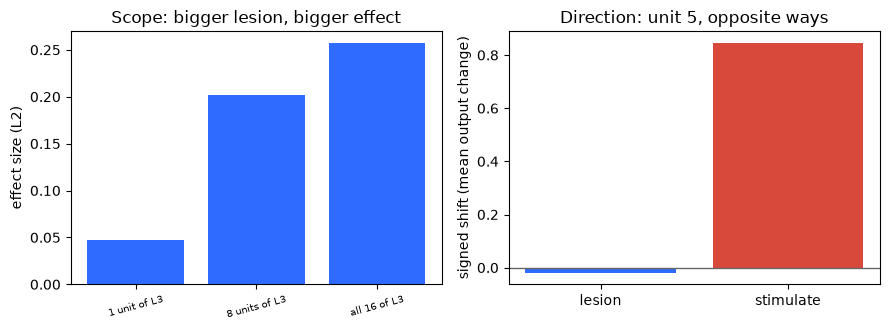

In [4]:
# Re-run the scope sweep, keeping just the L2 effect size for the bar chart.
effs = [apply(t, Perturbation(kind='zero'))[0] for _, t in scope]
# Left: effect vs lesion scope. Right: signed shift, lesion vs stimulation.
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].bar([n for n, _ in scope], effs, color='#2f6bff')
ax[0].set_ylabel('effect size (L2)'); ax[0].set_title('Scope: bigger lesion, bigger effect')
ax[0].tick_params(axis='x', rotation=15, labelsize=7.5)
ax[1].bar(['lesion', 'stimulate'], [lesion_shift, stim_shift], color=['#2f6bff', '#d8483b'])
ax[1].axhline(0, c='0.4', lw=1); ax[1].set_ylabel('signed shift (mean output change)')
ax[1].set_title('Direction: unit 5, opposite ways')
fig.tight_layout(); plt.show()

**Reading it:** left — with the operation fixed, effect grows with the number of
units perturbed. Right — lesioning vs stimulating the *same* unit shifts the output
in opposite directions. Note the *sign* of a lesion's shift is not always negative;
it depends on that unit's downstream weights, so "lesion = suppression" is not a
safe assumption. Every change here was undone by its handle (next cell).

## Exact reset

In [5]:
# After every reset the network is bit-for-bit back to baseline.
with torch.no_grad(): restored = net(x).clone()
print('output identical to baseline after all resets:', bool(torch.equal(restored, base)))

output identical to baseline after all resets: True
